# Comparaison des implémentations efficaces de l'attention multi-têtes

Ce notebook compare différentes façons d’implémenter l’attention causale multi-têtes utilisée dans les grands modèles de langage de type décodeur, tels que GPT, Llama, etc.


In [1]:
import torch

torch.manual_seed(123)
if torch.backends.mps.is_available():
  device = torch.device("mps")  # Apple Silicon GPU (Metal)
elif torch.cuda.is_available():
  device = torch.device("cuda") # NVIDIA GPU
else:
  device = torch.device("cpu")   # CPU fallback

print(f"Using device: {device}")
print(f"Pytorch version: {torch.__version__}")

batch_size = 8
context_len = 1024
embed_dim = 768
embeddings = torch.randn((batch_size, context_len, embed_dim), device=device, requires_grad=True)


Using device: cuda
Pytorch version: 2.11.0+cu128


<br>
&nbsp;

## 1. Le Wrapper `CausalAttention` pour l'attention multi-têtes (MHA) du chapitre 3

In [2]:
import torch.nn as nn

class CausalAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length,
               dropout, qkv_bias=False):
    super().__init__()

    self.d_out   = d_out

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    self.dropout = nn.Dropout(dropout)

    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length),diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape

    # shape : (b, num_tokens, d_in)
    queries = self.W_query(x)
    keys    = self.W_key(x)
    values  = self.W_value(x)

    attn_scores = queries @ keys.transpose(1, 2)
    attn_scores.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens],
                                             -torch.inf)

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vecs = attn_weights @ values

    return context_vecs


class Ch03_MHA_Wrapper(nn.Module):

  def __init__(self, d_in, d_out, context_length,
               dropout, num_heads, qkv_bias=False):
    super().__init__()

    self.heads = nn.ModuleList(
        [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
         for _ in range(num_heads)]
    )

    self.out_proj = nn.Linear(d_out * num_heads, d_out * num_heads)

  def forward(self, x):
    context_vecs = torch.cat([head(x) for head in self.heads], dim=-1)
    return self.out_proj(context_vecs)


mha_ch03_wrapper = Ch03_MHA_Wrapper(
    d_in=embed_dim,
    d_out=embed_dim//12,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_ch03_wrapper(embeddings)
print(out.shape)

torch.Size([8, 1024, 768])


<br>
&nbsp;

## 2. L'attention multi-têtes du chapitre 3

In [3]:
class Ch03_MHA(nn.Module):
  def __init__(self, d_in, d_out, context_length,
               num_heads, dropout, qkv_bias=False):
    super().__init__()

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads # Reduce th projection dim to match desired output dim

    self.W_query  = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key    = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value  = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out) # Linear layer to combine the heads outputs

    self.dropout = nn.Dropout(dropout)

    self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape

    # Shape : (b, num_tokens, d_out)
    queries = self.W_query(x)
    keys     = self.W_key(x)
    values  = self.W_value(x)

    # We implicitly split the matrix by adding a `num_heads` dimension
    # Unroll last dim : (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
    keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values  = values.view(b, num_tokens, self.num_heads, self.head_dim)

    # Transpose : (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
    queries = queries.transpose(1, 2)
    keys    = keys.transpose(1, 2)
    values  = values.transpose(1, 2)

    # Compute scaled dot_product (aka self-attention) with a causal mask
    attn_scores = queries @ keys.transpose(2, 3) # Dot product for each head
    # Original mask truncated to the number of tokens and converted to booolean
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    # Use the mask to fill attention scores
    attn_scores.masked_fill_(mask_bool, -torch.inf)

    # Compute attention weights
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # Context_vectors
    context_vecs = (attn_weights @ values).transpose(1, 2) # Shape : (b, num_tokens, num_heads, head_dim)
    # Combine heads, where self.d_out = self.head_dim * self.num_heads
    context_vecs = context_vecs.contiguous().view(b, num_tokens, self.d_out)

    # Optional projection
    context_vecs = self.out_proj(context_vecs)

    return context_vecs


mha_ch03 = Ch03_MHA(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)


out = mha_ch03(embeddings)
print(out.shape)


torch.Size([8, 1024, 768])


<br>  
&nbsp;

## 3. Une alternative d’attention multi-têtes avec des poids combinés


* Le code de la classe `MultiHeadAttentionCombinedQKV` ci-dessous est basé sur un code aimablement partagé par [Rayed Bin Wahed](https://github.com/rasbt/LLMs-from-scratch/discussions/51).

* La principale différence entre la classe `MultiHeadAttentionCombinedQKV` et la classe `MultiHeadAttention` utilisée au chapitre 3 est que `MultiHeadAttentionCombinedQKV` utilise une seule matrice de poids, `self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)`, au lieu de matrices de poids séparées :

  * `self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)`
  * `self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)`
  * `self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)`

* Ici, `self.qkv` regroupe les trois matrices de poids `self.W_query`, `self.W_key` et `self.W_value` afin d’effectuer le calcul des requêtes (*queries*), clés (*keys*) et valeurs (*values*) en une seule étape.

* En utilisant `q, k, v = qkv.unbind(0)`, on obtient les tenseurs de requêtes, clés et valeurs individuels, qui sont ensuite utilisés de la même manière que dans la classe `MultiHeadAttention` du chapitre 3.


In [4]:
import torch.nn as nn

class MultiHeadAttentionCombinedQKV(nn.Module):
  def __init__(self, d_in, d_out, context_length,
               num_heads, dropout, qkv_bias=False):
    super().__init__()

    assert d_out % num_heads == 0, "d_out is indivisible by num_heads"

    self.d_out     = d_out
    self.num_heads = num_heads
    self.head_dim  = d_out // num_heads

    self.qkv  = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
    self.proj = nn.Linear(d_out, d_out)

    self.dropout = nn.Dropout(dropout)

    self.register_buffer(
        "mask",
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )

  def forward(self, x):
    batch_size, num_tokens, embed_dim = x.shape

    # (b, num_tokens, embed_dim) --> (b, num_tokens, 3 * embed_dim)
    qkv = self.qkv(x)

    # (b, num_tokens, 3 * embed_dim) --> (b, num_tokens, 3, num_heads, head_dim)
    qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)

    # (b, num_tokens, 3, num_heads, head_dim) --> (3, b, num_heads, num_tokens, head_dim)
    qkv = qkv.permute(2, 0, 3, 1, 4)

    # (3, b, num_heads, num_tokens, head_dim) --> 3 times (b, num_heads, num_tokens, head_dim)
    queries, keys, values = qkv.unbind(0)

    # (b, num_heads, num_tokens, head_dim) --> (b, num_heads, num_tokens, num_tokens)
    attn_scores = queries @ keys.transpose(-2, -1)
    attn_scores = attn_scores.masked_fill_(
        self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
    )

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    # (b, num_heads, num_tokens, num_tokens) --> (b, num_heads, num_tokens, head_dim)
    context_vecs = attn_weights @ values

    # (b, num_heads, num_tokens, head_dim) --> (b, num_tokens, num_heads, head_dim)
    context_vecs = context_vecs.transpose(1, 2)

    # (b, num_tokens, num_heads, head_dim) --> (b, num_tokens, embed_dim)
    context_vecs = context_vecs.contiguous().view(batch_size, num_tokens, embed_dim)

    context_vecs = self.proj(context_vecs)

    return context_vecs


mha_combined_qkv = MultiHeadAttentionCombinedQKV(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length = context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_combined_qkv(embeddings)
print(out.shape)


torch.Size([8, 1024, 768])


## Transformations de dimensions dans MultiHeadAttentionCombined_QKV

### Étape 1 : Reshape initial
Après `W_qkv` (linear layer) : `(batch_size, num_tokens, 3, num_heads, head_dim)`

<img src="https://drive.google.com/uc?export=view&id=10Klxu1Jf4vrDZRElhGj1IYG5MchviVyq" width="800" alt="Reshape initial - QKV combined">

### Étape 2 : Réarrangement des dimensions
Après `permute` : `(3, batch_size, num_heads, num_tokens, head_dim)`

<img src="https://drive.google.com/uc?export=view&id=1piqv5hH85Vh5_UUqlVJmyG_4MTDDyKEN" width="3000" alt="Réarrangement - Dimension swap">

<br>
&nbsp;

## 4. Attention multi-têtes avec `Einsum`

* Implémentation de l'attention multi-têtes à l'aide de la sommation d'Einstein (*Einstein summation*) via [`torch.einsum`](https://pytorch.org/docs/stable/generated/torch.einsum.html).


In [5]:
import math
import torch
import torch.nn as nn


class MHAEinsum(nn.Module):
    """
    Multi-Head Attention avec einsum pour l'efficacité numérique.

    Implémente le mécanisme d'attention scaled dot-product multi-head
    avec masquage causal (futur masqué).

    Args:
        d_in: Dimension d'entrée
        d_out: Dimension de sortie (d_model dans Transformer)
        context_length: Longueur maximale de la séquence
        num_heads: Nombre de têtes d'attention
        dropout: Taux de dropout sur les poids d'attention
        qkv_bias: Utiliser des biais pour Q, K, V
    """

    def __init__(self, d_in, d_out, context_length, num_heads,
                 dropout, qkv_bias=False):
        super().__init__()

        # Vérifier que d_out est divisible par num_heads
        # Chaque tête aura une dimension de head_dim = d_out // num_heads
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        # Matrices de projection linéaire pour Q, K, V
        # Shape: (d_in, d_out) — projette d'entrée vers l'espace d'attention
        self.W_query = nn.Parameter(torch.randn(d_in, d_out))
        self.W_key = nn.Parameter(torch.randn(d_in, d_out))
        self.W_value = nn.Parameter(torch.randn(d_in, d_out))

        # Biais optionnels pour Q, K, V
        if qkv_bias:
            self.bias_q = nn.Parameter(torch.zeros(d_out))
            self.bias_k = nn.Parameter(torch.zeros(d_out))
            self.bias_v = nn.Parameter(torch.zeros(d_out))
        else:
            self.register_parameter("bias_q", None)
            self.register_parameter("bias_k", None)
            self.register_parameter("bias_v", None)

        # Projection de sortie : combine les têtes et ramène à d_out
        self.out_proj = nn.Linear(d_out, d_out)

        # Dropout sur les poids d'attention (avant agrégation)
        self.dropout = nn.Dropout(dropout)

        # Masque causal : triangle supérieur (positions futures)
        # Shape: (context_length, context_length)
        # Valeur 1 → sera masquée (mise à -inf), 0 → gardée
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

        # Initialiser les poids selon Kaiming
        self.reset_parameters()

    def reset_parameters(self):
        """Initialiser W_query, W_key, W_value avec Kaiming uniforme."""

        # Kaiming uniform pour les matrices de projection
        nn.init.kaiming_uniform_(self.W_query, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.W_key, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.W_value, a=math.sqrt(5))

        # Initialiser les biais uniformément
        # fan_in calcule le nombre d'entrées (crucial pour l'initialisation)
        if self.bias_q is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.W_query)
            bound = 1 / math.sqrt(fan_in)

            nn.init.uniform_(self.bias_q, -bound, bound)
            nn.init.uniform_(self.bias_k, -bound, bound)
            nn.init.uniform_(self.bias_v, -bound, bound)

    def forward(self, x):
        """
        Args:
            x: Entrée de shape (batch, seq_len, d_in)

        Returns:
            Sortie de shape (batch, seq_len, d_out)
        """
        b, n, _ = x.shape

        # ===== 1. Projections linéaires Q, K, V =====
        # einsum: "bnd,do->bno" = (batch, seq, d_in) @ (d_in, d_out) → (batch, seq, d_out)
        Q = torch.einsum("bnd,do->bno", x, self.W_query)
        K = torch.einsum("bnd,do->bno", x, self.W_key)
        V = torch.einsum("bnd,do->bno", x, self.W_value)

        # Ajouter les biais si présents
        if self.bias_q is not None:
            Q += self.bias_q
            K += self.bias_k
            V += self.bias_v

        # ===== 2. Restructurer pour multi-head =====
        # De (batch, seq, d_out) à (batch, num_heads, seq, head_dim)
        # .view() : reshape sans copier si mémoire contiguë
        # .transpose(1, 2) : échange seq et num_heads
        Q = Q.view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(b, n, self.num_heads, self.head_dim).transpose(1, 2)
        # Shape finale: (batch, num_heads, seq, head_dim)

        # ===== 3. Scaled dot-product attention =====
        # scores = Q @ K^T / √(d_head)
        # einsum: "bhnd,bhmd->bhnm" = (b, h, n, d) @ (b, h, m, d)^T → (b, h, n, m)
        # où n = seq_len (position query), m = seq_len (position key)
        scores = torch.einsum("bhnd,bhmd->bhnm", Q, K) / math.sqrt(self.head_dim)

        # ===== 4. Appliquer le masque causal =====
        # Masque: 1 pour positions futures, 0 pour positions présentes/passées
        # On coupe le masque à la longueur réelle : [:n, :n]
        mask = self.mask[:n, :n]

        # masked_fill : remplacer les positions masquées (mask==1) par -inf
        # Ainsi, softmax(scores + (-inf)) = 0 pour ces positions
        scores = scores.masked_fill(mask.bool(), -torch.inf)

        # ===== 5. Normaliser avec softmax et appliquer dropout =====
        attn_weights = torch.softmax(scores, dim=-1)  # Softmax sur la dim seq (m)
        attn_weights = self.dropout(attn_weights)      # Dropout pendant l'entraînement

        # ===== 6. Agréger les valeurs avec poids d'attention =====
        # context = attn_weights @ V
        # einsum: "bhnm,bhmd->bhnd" = (b, h, n, m) @ (b, h, m, d) → (b, h, n, d)
        context_vec = torch.einsum("bhnm,bhmd->bhnd", attn_weights, V)

        # ===== 7. Combiner les têtes et projeter =====
        # Retour à (batch, seq, d_out) : fusion des têtes
        # .transpose(1, 2) : (b, h, n, d) → (b, n, h, d)
        # .reshape(b, n, -1) : (b, n, h, d) → (b, n, h*d) = (b, n, d_out)
        context_vec = context_vec.transpose(1, 2).reshape(b, n, self.d_out)

        # Projection de sortie linéaire
        context_vec = self.out_proj(context_vec)

        return context_vec


mha_einsum = MHAEinsum(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)


out = mha_einsum(embeddings)
print(out.shape)

torch.Size([8, 1024, 768])


<br>
&nbsp;

## 5. Attention multi-tête avec scaled_dot_product_attention et FlexAttention de PyTorch

* L'implémentation ci-dessous utilise la fonction [`scaled_dot_product_attention`](https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html) de PyTorch, qui met en œuvre une version de l'auto-attention optimisée en mémoire appelée **FlashAttention**.


In [6]:
class MHAPyTorchScaledDotProduct(nn.Module):
    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out is indivisible by num_heads"

        self.num_heads = num_heads
        self.context_length = context_length
        self.head_dim = d_out // num_heads
        self.d_out = d_out

        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
        self.proj = nn.Linear(d_out, d_out)
        self.dropout = dropout

    def forward(self, x):
        batch_size, num_tokens, embed_dim = x.shape

        # (b, num_tokens, embed_dim) --> (b, num_tokens, 3 * d_out)
        qkv = self.qkv(x)

        # (b, num_tokens, 3 * d_out) --> (b, num_tokens, 3, num_heads, head_dim)
        qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)

        # (b, num_tokens, 3, num_heads, head_dim) --> (3, b, num_heads, num_tokens, head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        # (3, b, num_heads, num_tokens, head_dim) -> 3 times (b, num_heads, num_tokens, head_dim)
        queries, keys, values = qkv

        # Disable dropout during evaluation, apply dropout rate during training
        use_dropout = 0. if not self.training else self.dropout

        # Compute scaled dot-product attention with causal masking
        # (b, num_heads, num_tokens, head_dim) x 3 --> (b, num_heads, num_tokens, head_dim)
        context_vec = nn.functional.scaled_dot_product_attention(
            queries, keys, values, attn_mask=None, dropout_p=use_dropout, is_causal=True)

        # Transpose heads back: (b, num_heads, num_tokens, head_dim) --> (b, num_tokens, num_heads, head_dim)
        # Then reshape to combine heads: (b, num_tokens, num_heads, head_dim) --> (b, num_tokens, d_out)
        context_vec = context_vec.transpose(1, 2).contiguous().view(batch_size, num_tokens, self.d_out)

        # Project output: (b, num_tokens, d_out) --> (b, num_tokens, d_out)
        context_vec = self.proj(context_vec)

        return context_vec

In [7]:
mha_pytorch_scaled = MHAPyTorchScaledDotProduct(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_pytorch_scaled(embeddings)
print(out.shape)

torch.Size([8, 1024, 768])


<br>
&nbsp;

## 6. Attention multi-tête avec scaled_dot_product_attention sans FlexAttention

* Cette implémentation est similaire à la précédente, à la différence que nous désactivons **FlashAttention** en fournissant explicitement un masque causal (*causal mask*).


In [8]:
import torch
import torch.nn as nn


class MHAPytorchSDPAWithoutFlash(nn.Module):
    def __init__(self, d_in, d_out, context_length, num_heads,
                 dropout=0.0, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out is indivisible by num_heads"

        self.num_heads = num_heads
        self.d_out = d_out
        self.context_length = context_length
        self.head_dim = d_out // num_heads

        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = dropout
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1).bool())

    def forward(self, x):
        batch_size, num_tokens, embed_dim = x.shape

        # (B, T, D_in) --> (B, T, 3*D_out)
        qkv = self.qkv(x)

        # (B, T, 3*D_out) --> (B, T, 3, num_heads, head_dim)
        qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)

        # (B, T, 3, num_heads, head_dim) --> (3, B, num_heads, T, head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        # Unpack Q, K, V: 3 x (B, num_heads, T, head_dim)
        queries, keys, values = qkv

        # Apply dropout only during training
        use_dropout = 0. if not self.training else self.dropout

        # Slice causal mask to sequence length
        attn_mask = self.mask[:num_tokens, :num_tokens]

        # Scaled dot-product attention with causal masking
        context_vec = nn.functional.scaled_dot_product_attention(
            queries, keys, values, attn_mask=attn_mask, dropout_p=use_dropout, is_causal=False
        )

        # Transpose and reshape: (B, num_heads, T, head_dim) --> (B, T, D_out)
        context_vec = context_vec.transpose(1, 2).contiguous().view(batch_size, num_tokens, self.d_out)

        # Output projection
        context_vec = self.out_proj(context_vec)

        return context_vec

In [9]:
mha_pytorch_sdpa_no_flash = MHAPytorchSDPAWithoutFlash(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_pytorch_sdpa_no_flash(embeddings)
print(out.shape)

torch.Size([8, 1024, 768])


<br>
&nbsp;

## 7. Utilisation de `torch.nn.MultiheadAttention` de PyTorch

* Ci-dessous, nous utilisons l’implémentation de l’attention multi-têtes fournie par PyTorch via `torch.nn.MultiheadAttention`.


In [10]:
import torch
import torch.nn as nn


class MHAPyTorchClass(nn.Module):
    """
    Multi-head self-attention module using PyTorch's nn.MultiheadAttention.

    Tensor shape notation:
    - B: batch size
    - T: sequence length (number of tokens)
    - D: embedding dimension
    """

    def __init__(self, d_in, d_out, num_heads, context_length, dropout=0.0, qkv_bias=False, need_weights=True):
        super().__init__()

        self.context_length = context_length

        # Multi-head attention with batch_first convention: (B, T, D)
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=d_out,
            num_heads=num_heads,
            dropout=dropout,
            bias=qkv_bias,
            add_bias_kv=qkv_bias,
            batch_first=True,
        )

        # need_weights: whether to return attention weights (B, num_heads, T, T)
        # Set to False to save memory if attention weights are not needed
        self.need_weights = need_weights
        self.proj = nn.Linear(d_out, d_out)

        # Causal mask: (context_length, context_length)
        # True indicates positions to mask out (future tokens)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1).bool()
        )

    def forward(self, x):
        # x: (B, T, D)
        batch_size, num_tokens, _ = x.shape

        # Slice causal mask to sequence length: (T, T)
        attn_mask = self.mask[:num_tokens, :num_tokens]

        # Self-attention: x projected to Q, K, V via internal weight matrices
        # Input: (B, T, D) | Output: (B, T, D)
        attn_output, _ = self.multihead_attn(
            x, x, x,
            attn_mask=attn_mask,
            need_weights=self.need_weights
        )

        # Output projection: (B, T, D) -> (B, T, D)
        output = self.proj(attn_output)

        return output

In [11]:
mha_pytorch_class_default = MHAPyTorchClass(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False
).to(device)

out = mha_pytorch_class_default(embeddings)
print(out.shape)

torch.Size([8, 1024, 768])


## 8. Utiliser torch.nn.MultiheadAttention avec `scaled_dot_product_attention`
- Définir `need_weights` (défaut `True`) à `False` pour que `MultiheadAttention` utilise `scaled_dot_product_attention` [selon la documentation](https://github.com/pytorch/pytorch/blob/71d020262793542974cf13b30f2a9099773f015c/torch/nn/modules/activation.py#L1096)
```markdown
need_weights: Si spécifié, retourne `attn_output_weights` en plus de `attn_outputs`.
           Définir `need_weights=False` pour utiliser l'implémentation optimisée
           `scaled_dot_product_attention` et obtenir les meilleures performances pour MHA.
           Défaut: `True`
```

In [12]:
mha_pytorch_class_noweights = MHAPyTorchClass(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=context_len,
    dropout=0.0,
    num_heads=12,
    qkv_bias=False,
    need_weights=False
).to(device)

out = mha_pytorch_class_noweights(embeddings)
print(out.shape)

torch.Size([8, 1024, 768])


<br>
&nbsp;

## 9. Utiliser FlexAttention de PyTorch

- Consultez [FlexAttention: The Flexibility of PyTorch with the Performance of FlashAttention](https://pytorch.org/blog/flexattention/) pour en savoir plus sur FlexAttention
- Limitation de FlexAttention : Elle ne supporte pas encore le dropout
- Ceci est supporté à partir de PyTorch 2.5, que vous pouvez installer sur une machine CPU via

    ```bash
    pip install torch torchvision torchaudio
    ```

- Pour installer PyTorch sur une machine GPU, utilisez la commande suivante (pour plus d'informations, consultez aussi le menu d'installation sur [pytorch.org](https://pytorch.org/))

    ```bash
    pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
    ```

In [13]:
from packaging.version import parse as parse_version

def normalize_version(version):
    """
    Normalise la chaîne de version au format de versioning sémantique (majeur.mineur.micro).
    Supprime les identifiants de pré-version (alpha, beta, rc) et les métadonnées de build.

    Pourquoi ? Pour comparer les versions de manière fiable (ex: "2.5.0rc1" < "2.5.0" < "2.5.1")

    Exemple :
        "2.5.0rc1" -> "2.5.0"
        "2.5.0.dev20240101" -> "2.5.0"
        "2.5" -> "2.5.0"

    Mécanisme :
    1. parse_version() : convertit la chaîne en objet Version avec extraction des composants
    2. Accès à .major, .minor, .micro : récupère les trois nombres clés
    3. String formatting : reconstruit une version "propre" sans pré-versions
    4. parse_version() à nouveau : reconvertit en objet Version pour comparaison
    """

    # ÉTAPE 1 : Parser la version brute
    # "2.5.0rc1" --> objet Version avec attributs :
    #   .major = 2
    #   .minor = 5
    #   .micro = 0
    #   (ignore "rc1")
    parsed_version = parse_version(version)

    # ÉTAPE 2 : Extraire major.minor.micro et ignorer le reste
    # Exemple : si parsed_version est "2.5.0rc1"
    #   f"{2}.{5}.{0}" = "2.5.0"
    # On reconstruit UNE VERSION PROPRE sans rc1, dev, etc.
    normalized_string = f"{parsed_version.major}.{parsed_version.minor}.{parsed_version.micro}"

    # ÉTAPE 3 : Reconvertir en objet Version pour pouvoir le comparer
    # "2.5.0" --> objet Version (maintenant "pur", sans pré-versions)
    return parse_version(normalized_string)


In [14]:
current_version = normalize_version(torch.__version__)
MIN_TORCH_VERSION = "2.5.0"
required_version = parse_version(MIN_TORCH_VERSION)

In [15]:
if current_version >= required_version and torch.cuda.is_available():
    from torch.nn.attention.flex_attention import flex_attention, create_block_mask

def causal(b, h, q_idx, kv_idx):
    """
    Fonction de masque d'attention causale pour FlexAttention.
    Retourne True si la requête à la position q_idx peut attendre la clé-valeur à kv_idx.

    Règle causale : q_idx >= kv_idx
    - Position 0 peut attendre : position 0 uniquement
    - Position 1 peut attendre : positions 0, 1
    - Position t peut attendre : positions 0 à t (pas d'attente vers l'avant)

    Paramètres :
    - b: indice du batch (non utilisé ici, mais fourni par FlexAttention)
    - h: indice de la tête (non utilisé ici, attention identique pour tous les heads)
    - q_idx: indice de position de la requête dans la séquence
    - kv_idx: indice de position de la clé-valeur dans la séquence
    """
    return q_idx >= kv_idx

class MHAPyTorchFlexAttention(nn.Module):
    """
    Attention multi-tête utilisant FlexAttention de PyTorch.

    FlexAttention est un kernel d'attention fusionné et optimisé qui :
    - Fusionne les opérations softmax et multiplication matricielle
    - Réduit les accès mémoire (plus rapide que les implémentations naïves)
    - Supporte les masques causaux personnalisés

    Prérequis :
    - PyTorch >= 2.5.0
    - CUDA disponible (GPU)

    Notation des formes tensorielles :
    - B: taille du batch (nombre d'exemples parallèles)
    - T: longueur de la séquence (nombre de tokens)
    - D: dimension d'embedding (taille de la représentation)
    - h: nombre de têtes d'attention
    - d_head: dimension par tête (D / h)
    """

    def __init__(self, d_in, d_out, num_heads, context_length,
                 dropout=0.0, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out est indivisible par num_heads"

        self.num_heads = num_heads
        self.context_length = context_length
        self.head_dim = d_out // num_heads  # Dimension de chaque tête
        self.d_out = d_out

        # Projection combinée pour Q, K, V
        # Entrée : (B, T, d_in)
        # Sortie : (B, T, 3 * d_out) où on aura [Q, K, V] concaténés
        self.qkv = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)

        # Projection de sortie après l'attention
        self.proj = nn.Linear(d_out, d_out)

        # Note : FlexAttention ne supporte pas le dropout en tant que paramètre
        # Le dropout doit être géré séparément si nécessaire
        self.dropout = dropout

    def forward(self, x):
        """
        Forward pass de l'attention multi-tête.

        Paramètres :
        - x: (B, T, d_in) tenseur d'entrée

        Retour :
        - output: (B, T, d_out) représentation après attention
        """
        batch_size, num_tokens, embed_dim = x.shape

        # ===== ÉTAPE 1 : Projection linéaire combinée =====
        # (B, T, d_in) @ W_qkv --> (B, T, 3 * d_out)
        # Ceci crée les trois matrices Q, K, V empilées dans une seule opération
        qkv = self.qkv(x)

        # ===== ÉTAPE 2 : Reshaper pour séparer les têtes =====
        # (B, T, 3 * d_out) --> (B, T, 3, num_heads, d_head)
        # Exemple : si d_out=768, num_heads=12, d_head=64
        #   (B, T, 2304) --> (B, T, 3, 12, 64)
        qkv = qkv.view(batch_size, num_tokens, 3, self.num_heads, self.head_dim)

        # ===== ÉTAPE 3 : Réorganiser pour FlexAttention =====
        # (B, T, 3, num_heads, d_head) --> (3, B, num_heads, T, d_head)
        # Ceci place les 3 matrices Q, K, V en première dimension pour les déballer facilement
        qkv = qkv.permute(2, 0, 3, 1, 4)

        # ===== ÉTAPE 4 : Déballer Q, K, V =====
        # (3, B, num_heads, T, d_head) --> 3 tenseurs de (B, num_heads, T, d_head)
        # Forme attendue par FlexAttention (et scaled_dot_product_attention)
        queries, keys, values = qkv

        # ===== ÉTAPE 5 : Créer le masque causal =====
        # FlexAttention n'accepte pas les masques pré-calculés et slicés (PyTorch 2.5+)
        # Doit créer un nouveau BlockMask à chaque forward avec les bonnes dimensions
        #
        # create_block_mask retourne un objet BlockMask qui encode la fonction causal
        # Q_LEN = T (longueur requête)
        # KV_LEN = T (longueur clé-valeur)
        # Pour self-attention, ces deux sont toujours égales
        attn_mask = create_block_mask(
            causal,                    # Fonction de masque : q_idx >= kv_idx
            B=None,                    # Flexible sur la dimension batch
            H=None,                    # Flexible sur la dimension heads (même masque pour toutes)
            Q_LEN=num_tokens,          # Longueur de la séquence requête
            KV_LEN=num_tokens,         # Longueur de la séquence clé-valeur
            device=x.device            # Placer le masque sur le même device (CPU/GPU)
        )

        # ===== ÉTAPE 6 : Appliquer FlexAttention =====
        # FlexAttention est un kernel fusionné qui calcule :
        #   attention = softmax(Q @ K^T / sqrt(d_head) + masque) @ V
        #
        # Entrée :
        # - queries: (B, num_heads, T, d_head)
        # - keys: (B, num_heads, T, d_head)
        # - values: (B, num_heads, T, d_head)
        # - block_mask: BlockMask encodant la fonction causal
        #
        # Sortie : (B, num_heads, T, d_head)
        context_vec = flex_attention(queries, keys, values, block_mask=attn_mask)

        # ===== ÉTAPE 7 : Recombiner les têtes =====
        # (B, num_heads, T, d_head) --> (B, T, num_heads, d_head)
        # Transpose pour ramener num_heads en position 2 (avant le reshape)
        context_vec = context_vec.transpose(1, 2)

        # Appel à contiguous() : garantit que le tenseur est contigu en mémoire
        # (peut être nécessaire après une transposition)
        context_vec = context_vec.contiguous()

        # (B, T, num_heads, d_head) --> (B, T, d_out)
        # Reshape : concatène toutes les têtes en une seule dimension
        # Exemple : (2, 512, 12, 64) --> (2, 512, 768)
        context_vec = context_vec.view(batch_size, num_tokens, self.d_out)

        # ===== ÉTAPE 8 : Projection de sortie =====
        # (B, T, d_out) @ W_proj --> (B, T, d_out)
        # Cette projection apprend à combiner les informations d'attention
        context_vec = self.proj(context_vec)

        return context_vec

In [16]:
if current_version >= required_version and torch.cuda.is_available():

    mha_pytorch_flex = MHAPyTorchFlexAttention(
        d_in=embed_dim,
        d_out=embed_dim,
        context_length=context_len,
        dropout=0.0,
        num_heads=12,
        qkv_bias=False
    ).to(device)

    mha_pytorch_flex = torch.compile(mha_pytorch_flex)  # Compiler le module

    out = mha_pytorch_flex(embeddings)
    print(out.shape)

torch.Size([8, 1024, 768])


## FlashAttention vs FlexAttention

**FlashAttention** : Algorithme d'optimisation qui réduit drastiquement
la mémoire et le temps via la fusion d'opérations et le traitement par blocs.
- Limité aux masques causaux standards

**FlexAttention** : Implémentation PyTorch native de FlashAttention (2.5+)
- Ajoute le support des masques custom via des fonctions
- Combine vitesse (FlashAttention) + flexibilité (masques personnalisés)

<br>
&nbsp;

## 10. Comparaison rapide des performances

<br>
&nbsp;

### 10.1 Comparaison des performances sur le CPU de Google Colab

In [17]:
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [18]:
torch.manual_seed(123)

# Cette section teste spécifiquement sur CPU
device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Running on {device}")

PyTorch version: 2.11.0+cu128
Running on cpu


In [19]:
## 1) CausalAttention MHA wrapper class from chapter 3
%timeit mha_ch03_wrapper(embeddings)

39.6 ms ± 1.22 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [20]:
## 2) The multi-head attention class from chapter 3
%timeit mha_ch03(embeddings)

39 ms ± 1.66 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [21]:
## 3) An alternative multi-head attention with combined weights
%timeit mha_combined_qkv(embeddings)

34.7 ms ± 122 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [22]:
## 4) Multi-head attention using Einstein summation
%timeit mha_einsum(embeddings)

49.1 ms ± 2.98 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [23]:
## 5) Multi-head attention with PyTorch's scaled dot product attention
%timeit mha_pytorch_scaled(embeddings)

16 ms ± 5 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [24]:
## 6) PyTorch's scaled dot product attention without FlashAttention
%timeit mha_pytorch_sdpa_no_flash(embeddings)

37.9 ms ± 455 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [25]:
## 7) Using PyTorch's torch.nn.MultiheadAttention
%timeit mha_pytorch_class_default(embeddings)

67.6 ms ± 22.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [26]:
## 8) Using PyTorch's torch.nn.MultiheadAttention disabling `need_weights`
%timeit mha_pytorch_class_noweights(embeddings)

27.9 ms ± 401 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [27]:
## 9) Using PyTorch's FlexAttention

# Requires PyTorch 2.5.0 or newer and currently only supports CUDA Pytorch
%timeit mha_pytorch_flex(embeddings)

23.2 ms ± 451 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


<br>
&nbsp;

### 10.2 Comparaison rapide des performances sur GPU Nvidia T4

In [28]:
# Enable tensor cores
torch.set_float32_matmul_precision("high")

In [29]:
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [30]:
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Running on {device}")

PyTorch version: 2.11.0+cu128
Running on cuda


In [31]:
## 1) CausalAttention MHA wrapper class from chapter 3
%timeit mha_ch03_wrapper(embeddings)

43.3 ms ± 1.13 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [32]:
## 2) The multi-head attention class from chapter 3
%timeit mha_ch03(embeddings)

39.4 ms ± 578 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [33]:
## 3) An alternative multi-head attention with combined weights
%timeit mha_combined_qkv(embeddings)

32.4 ms ± 338 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [34]:
## 4) Multi-head attention using Einstein summation
%timeit mha_einsum(embeddings)

45.7 ms ± 2.51 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [35]:
## 5) Multi-head attention with PyTorch's scaled dot product attention
%timeit mha_pytorch_scaled(embeddings)

15.5 ms ± 4.82 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [36]:
## 6) PyTorch's scaled dot product attention without FlashAttention
%timeit mha_pytorch_sdpa_no_flash(embeddings)

37.8 ms ± 368 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [37]:
## 7) Using PyTorch's torch.nn.MultiheadAttention
%timeit mha_pytorch_class_default(embeddings)

68.2 ms ± 22.4 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [38]:
## 8) Using PyTorch's torch.nn.MultiheadAttention disabling `need_weights`
%timeit mha_pytorch_class_noweights(embeddings)

27.9 ms ± 414 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [39]:
## 9) Using PyTorch's FlexAttention

# Requires PyTorch 2.5.0 or newer
%timeit mha_pytorch_flex(embeddings)

510 µs ± 49.2 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


<br>
&nbsp;


## 11. Visualisations

<br>
&nbsp;

### 11.1 Fonctions utilitaires de visualisation

In [40]:
torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Runing on {device}")

PyTorch version: 2.11.0+cu128
Runing on cuda


In [41]:
functions = {
    "1) MHA wrapper class": mha_ch03_wrapper,
    "2) MHA Ch03": mha_ch03,
    "3) MHA with combined QKV weights": mha_combined_qkv,
    "4) MHA with Einsum": mha_einsum,
    "5) MHA with PyTorch scaled_dot_product_attention": mha_pytorch_scaled,
    "6) PyTorch's SDPA, no FlashAttention": mha_pytorch_sdpa_no_flash,
    "7) PyTorch MHA class defaults": mha_pytorch_class_default,
    "8) Pytorch MHA with need_weights=False": mha_pytorch_class_noweights
}

if current_version >= required_version and torch.cuda.is_available():
  functions["9) Pytorch's FlexAttention"] = mha_pytorch_flex

In [42]:
import matplotlib.pyplot as plt

# Configuration dark mode (esthétique sombre)
plt.rcParams["figure.facecolor"] = "#121212"      # Arrière-plan figure : noir foncé
plt.rcParams["axes.facecolor"] = "#121212"        # Arrière-plan axes : noir foncé
plt.rcParams["axes.edgecolor"] = "white"          # Bordure axes : blanc
plt.rcParams["axes.labelcolor"] = "white"         # Étiquettes axes : blanc
plt.rcParams["text.color"] = "white"              # Texte général : blanc
plt.rcParams["xtick.color"] = "white"             # Ticks axe X : blanc
plt.rcParams["ytick.color"] = "white"             # Ticks axe Y : blanc
plt.rcParams["grid.color"] = "#444444"            # Grille : gris foncé
plt.rcParams["lines.linewidth"] = 2               # Épaisseur lignes : 2px
plt.rcParams["lines.markersize"] = 8              # Taille marqueurs : 8px


def plot_execution_times(functions, executions_means, execution_stds, filename):
    """
    Crée un histogramme comparant les temps d'exécution de plusieurs fonctions.

    Paramètres :
    - functions: dict avec noms des fonctions (clés)
    - executions_means: list des temps moyens d'exécution (ms)
    - execution_stds: list des écarts-types (barres d'erreur)
    - filename: chemin où sauvegarder le graphique
    """

    # ===== CRÉER LA FIGURE =====
    # fig = la figure globale
    # ax = les axes (où on dessine)
    fig, ax = plt.subplots()

    # ===== CRÉER LES BARRES =====
    # ax.bar() crée un histogramme
    # - functions.keys() : noms des fonctions (labels sur X)
    # - executions_means : hauteur des barres
    # - yerr=execution_stds : écarts-types (barres d'erreur verticales)
    # - capsize=5 : taille des "chapeaux" sur les barres d'erreur
    # - error_kw={'ecolor':'grey'} : couleur des barres d'erreur (gris)
    bars = ax.bar(functions.keys(), executions_means,
                  yerr=execution_stds, capsize=5, error_kw={'ecolor':'grey'})

    # ===== LABELS ET TICKS =====
    plt.ylabel("Execution time (ms)")              # Étiquette axe Y
    plt.xticks(rotation=45, ha="right")           # Tourner labels X de 45° vers la droite

    # ===== CALCULER LA LIMITE SUPÉRIEURE DE L'AXE Y =====
    # On veut laisser de la place au-dessus des barres pour les annotations
    max_execution_time = max(executions_means)    # Temps max parmi les données
    upper_ylim = max_execution_time + 0.4 * max_execution_time
    # Exemple : si max=100ms, alors upper_ylim = 100 + 40 = 140ms
    plt.ylim(0, upper_ylim)                       # Y va de 0 à 140ms

    # ===== ANNOTER CHAQUE BARRE AVEC SA VALEUR =====
    for bar in bars:
        # Récupérer la hauteur de la barre (temps d'exécution)
        yval = bar.get_height()

        # Placer un texte au-dessus de la barre
        # Position X : centre de la barre
        # Position Y : au-dessus, avec 5% de marge
        plt.text(
            bar.get_x() + bar.get_width()/2,      # X : centre de la barre
            yval + (0.05 * upper_ylim),           # Y : au-dessus avec marge
            round(yval, 2),                       # Texte : valeur arrondie
            ha="center",                          # Alignement horizontal : centre
            va="bottom"                           # Alignement vertical : bas du texte
        )

    # ===== FINALISER ET SAUVEGARDER =====
    plt.tight_layout()                           # Ajuste les espaces automatiquement
    plt.savefig(filename)                        # Sauvegarde dans un fichier
    plt.show()                                   # Affiche le graphique

<br>
&nbsp;

### 11.2 Comparaison de vitesse (GPU Nvidia T4) avec warmup (forward pass uniquement)

In [43]:
# CUDA benchmark code shared by Andrei Aksionov
# and based on code from
# https://github.com/cuda-mode/lectures/blob/main/lecture1/pytorch_square.py

import numpy as np

def time_pytorch_function(func, *input, num_repeats=1_000):
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    # Warmup
    for _ in range(5):
        func(*input)
    torch.cuda.synchronize()

    times = []
    for _ in range(num_repeats):
        start.record()
        func(*input)
        end.record()
        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))

    return np.mean(times), np.std(times)

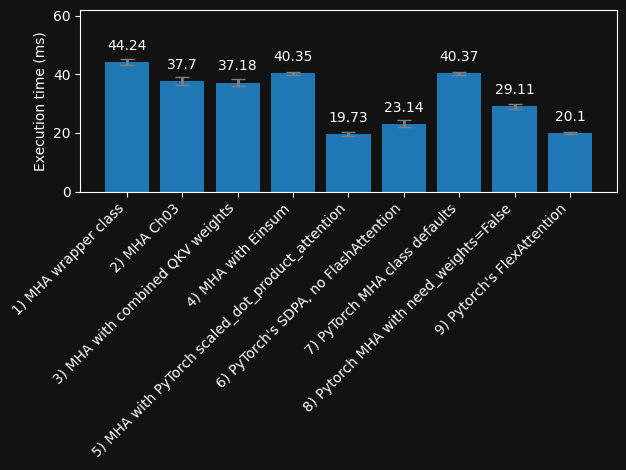

In [44]:
execution_stats = [time_pytorch_function(fn, embeddings) for fn in functions.values()]
execution_means = [stat[0] for stat in execution_stats]
execution_stds = [stat[1] for stat in execution_stats]


plot_execution_times(functions, execution_means, execution_stds, filename="1_forward-only.pdf")

<br>
&nbsp;

### 11.3 Comparaison de vitesse (GPU Nvidia T4) avec warmup (forward et backward pass)

In [45]:
def forward_backward(func, embeddings):
    if embeddings.grad is not None:
        embeddings.grad.zero_()

    output = func(embeddings)
    loss = output.sum()
    loss.backward()


def time_pytorch_function_forward_backward(func, *input, num_repeats = 1_000):
    # CUDA IS ASYNC so can't use python time module
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    # Warmup
    for _ in range(5):
        forward_backward(func, *input)
    torch.cuda.synchronize()

    times = []
    for _ in range(num_repeats):
        start.record()
        forward_backward(func, *input)
        end.record()
        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))

    return np.mean(times), np.std(times)

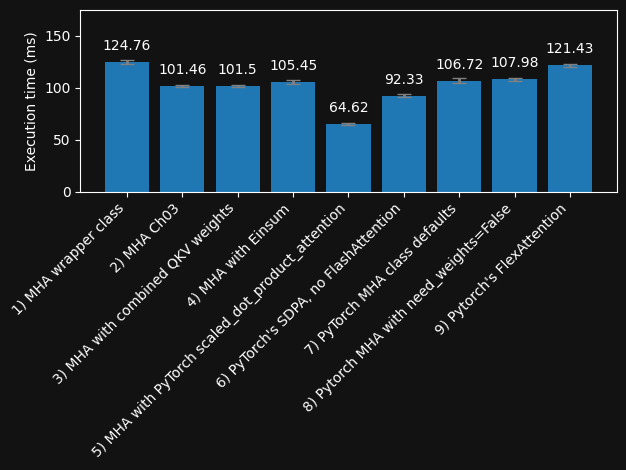

In [46]:
execution_stats = [time_pytorch_function_forward_backward(fn, embeddings) for fn in functions.values()]
execution_means = [stat[0] for stat in execution_stats]
execution_stds = [stat[1] for stat in execution_stats]


plot_execution_times(functions, execution_means, execution_stds, filename="2_forward-and-backward.pdf")

<br>
&nbsp;

### 11.4 Comparaison de vitesse (GPU Nvidia T4) avec warmup et compilation (forward et backward pass)

In [47]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

def prepare_function(fn):
    fn = torch.compile(fn)
    return fn

W0626 02:21:47.042000 46522 torch/_inductor/utils.py:1731] [7/0] Not enough SMs to use max_autotune_gemm mode


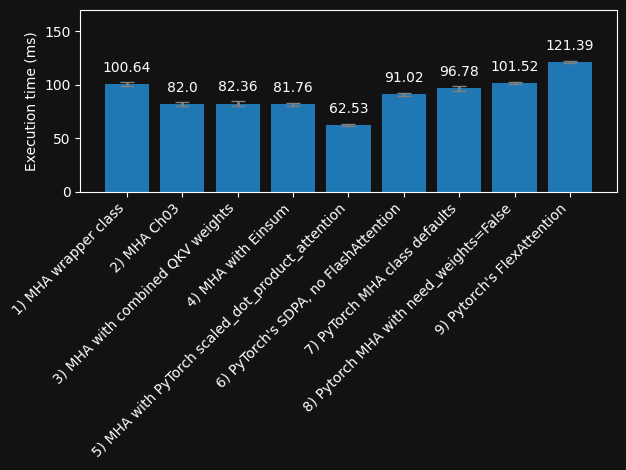

In [48]:
execution_stats = [time_pytorch_function_forward_backward(prepare_function(fn), embeddings) for fn in functions.values()]
execution_means = [stat[0] for stat in execution_stats]
execution_stds = [stat[1] for stat in execution_stats]


plot_execution_times(functions, execution_means, execution_stds, filename="3_forward-and-backward-compiled.pdf")